# Vergleich: Gesichtsausrichtung


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, spearmanr


In [9]:
DATA_DIR = Path('../../data')

INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '04_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_angle_face_orientation.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
print(df[['influencer_type', 'face_pitch_mean', 'face_yaw_mean', 'detected_face_frames']].groupby('influencer_type').agg(['count', 'mean', 'std']))


Reading ../../data/04_analysis_results/visual_features/04_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_angle_face_orientation.csv                face_pitch_mean                     face_yaw_mean            \                          count      mean       std         count      mean   influencer_type                                                               ai                          247  6.948431  4.987724           247 -0.717536   real                        244  6.225828  6.199896           244 -0.559216                              detected_face_frames                                            std                count    mean        std  influencer_type                                                     ai               13.615196                  250  15.904  15.406108  real             11.849773                  250  33.800  44.518576  

In [10]:
FRAME_ROOT = DATA_DIR / '02_media/stratified_sample/frames'

def get_video_id(row):
    return str(row.get('id') or row.get('video_id'))

def first_frame_path(video_id: str):
    folder = FRAME_ROOT / video_id
    if not folder.is_dir():
        return None
    frames = sorted(folder.glob('*.jpeg'))
    if not frames:
        frames = sorted(folder.glob('*.jpg'))
    if not frames:
        return None
    return frames[len(frames) // 2]

def load_image(path):
    import cv2
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


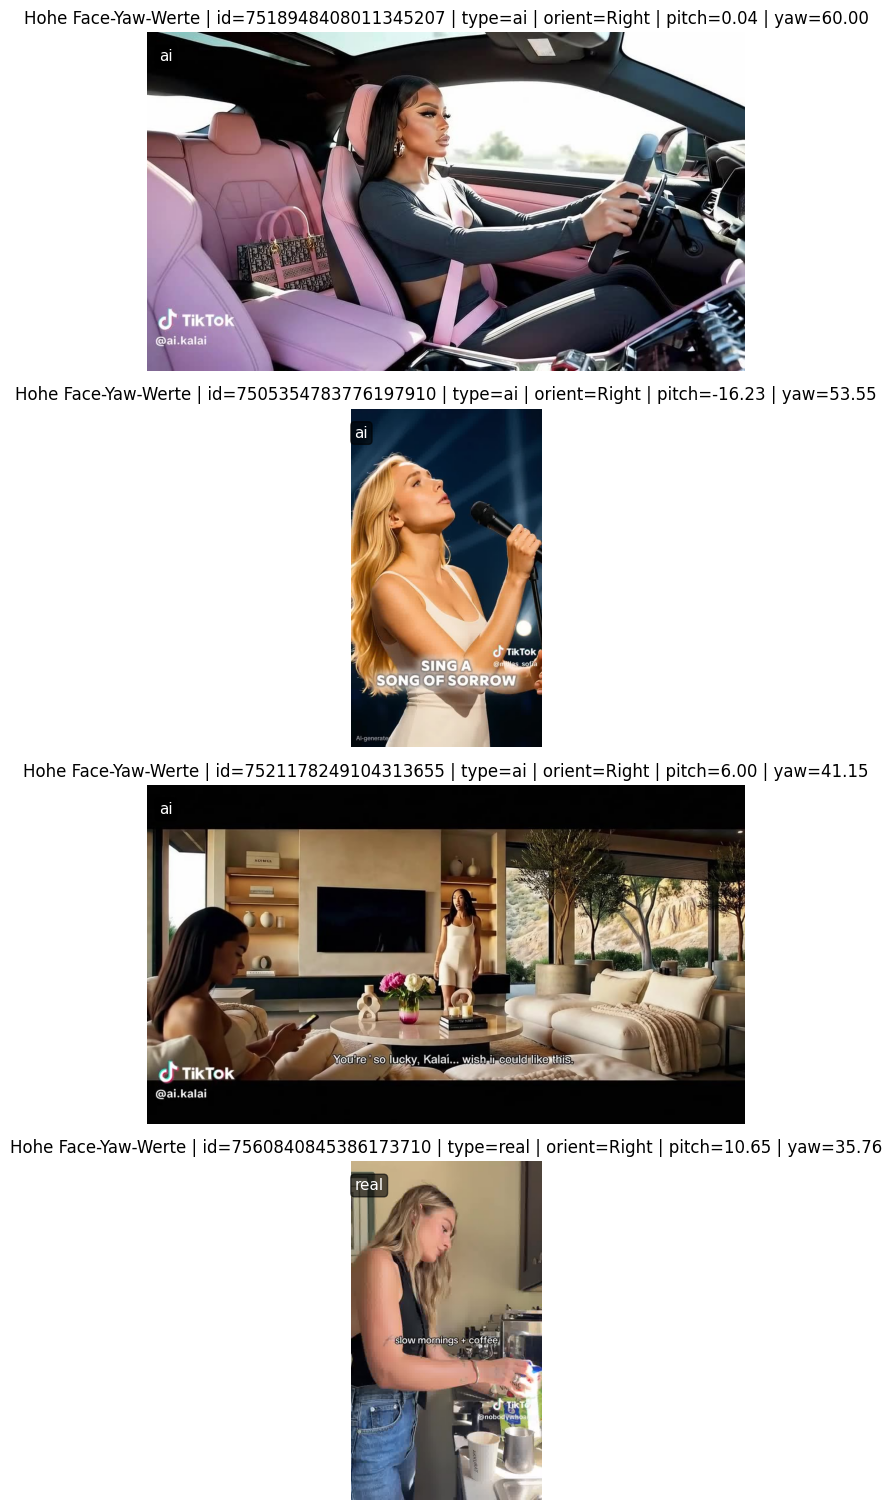

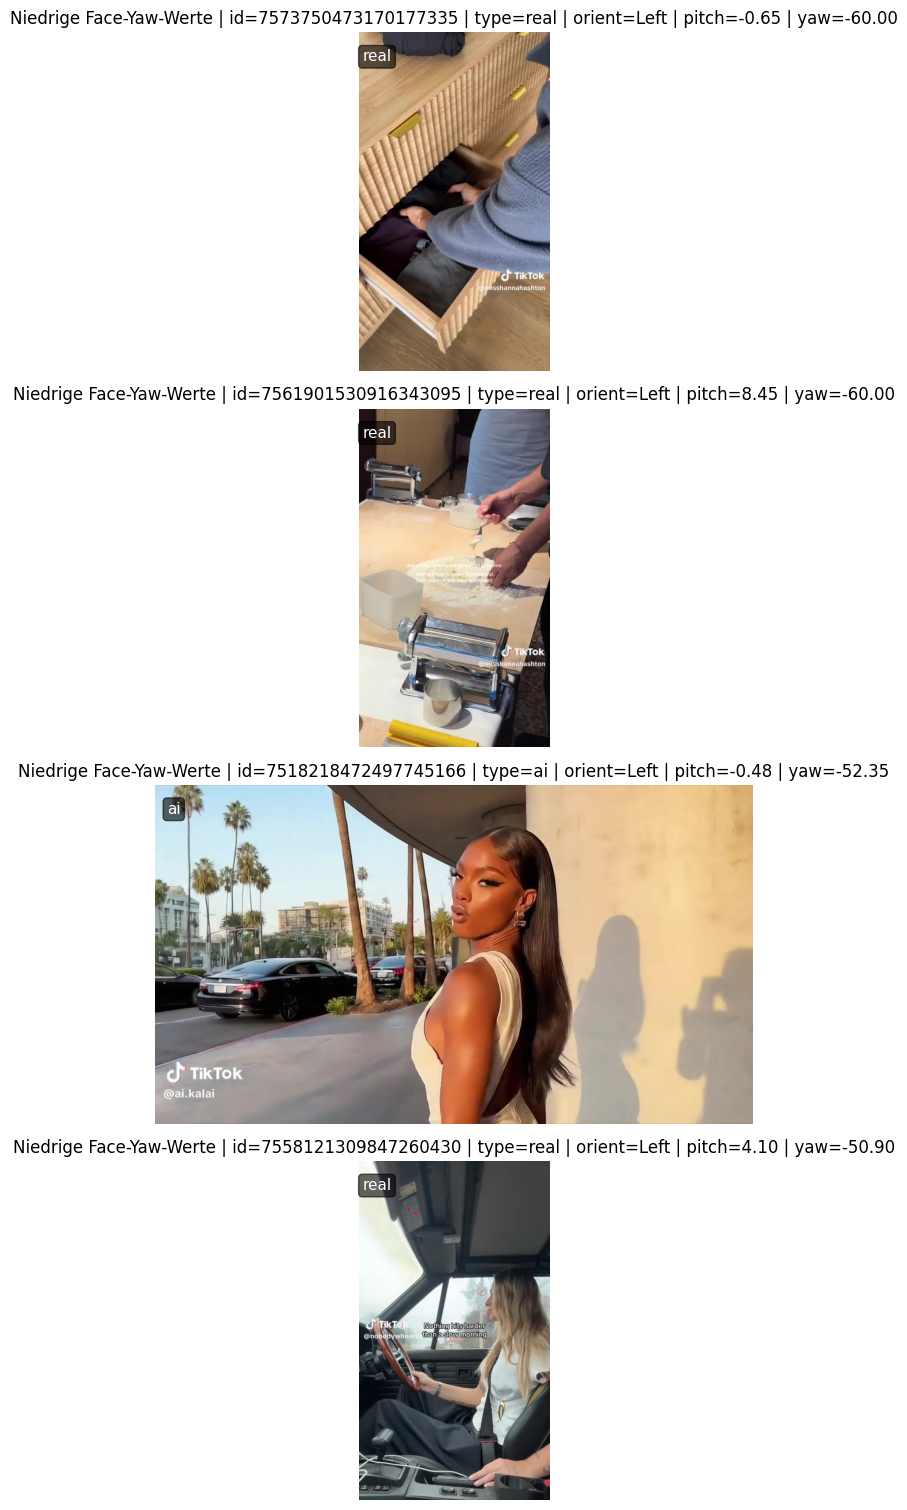

In [10]:
# Beispiele mit hohen und niedrigen Gierwinkeln anzeigen
_df = df.dropna(subset=['face_yaw_mean']).copy()

def pick_examples(df_sorted, n=4):
    rows = []
    for _, row in df_sorted.iterrows():
        vid = get_video_id(row)
        fp = first_frame_path(vid)
        if fp is None:
            continue
        row = row.copy()
        row['frame_path'] = fp
        rows.append(row)
        if len(rows) >= n:
            break
    return rows

def show_examples(rows, title):
    if not rows:
        print(f'No frames found for {title}')
        return

    plt.figure(figsize=(12, 3.8 * len(rows)))
    for i, row in enumerate(rows, 1):
        img = load_image(row['frame_path'])
        ax = plt.subplot(len(rows), 1, i)
        if img is not None:
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Image load failed', ha='center', va='center')
            ax.axis('off')

        yaw = row['face_yaw_mean']
        pitch = row.get('face_pitch_mean', np.nan)
        orient = row.get('angle_face_orientation', '')
        inf = row.get('influencer_type', '')
        vid = get_video_id(row)
        ax.text(0.02, 0.95, f'{inf}', transform=ax.transAxes, ha='left', va='top',
                fontsize=11, color='white',
                bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.6))
        ax.set_title(
            f'{title} | id={vid} | type={inf} | orient={orient} | pitch={pitch:.2f} | yaw={yaw:.2f}'
        )

    plt.tight_layout()
    plt.show()

high_yaw = pick_examples(_df.sort_values('face_yaw_mean', ascending=False), n=4)
low_yaw = pick_examples(_df.sort_values('face_yaw_mean', ascending=True), n=4)

show_examples(high_yaw, 'Hohe Face-Yaw-Werte')
show_examples(low_yaw, 'Niedrige Face-Yaw-Werte')


In [11]:
summary = df.groupby('influencer_type')[['face_pitch_mean', 'face_yaw_mean', 'detected_face_frames']].describe().round(2)
display(summary)

orientation_summary = (
    df.pivot_table(index='angle_face_orientation', columns='influencer_type', values='video_id', aggfunc='count', fill_value=0)
    if 'video_id' in df.columns
    else df.groupby(['angle_face_orientation', 'influencer_type']).size().unstack(fill_value=0)
)
display(orientation_summary)


face_pitch_mean                                               \
                          count  mean   std    min   25%   50%    75%    max   
influencer_type                                                                
ai                        247.0  6.95  4.99 -16.23  4.06  7.55  10.66  19.64   
real                      244.0  6.23  6.20 -38.29  3.55  6.77  10.10  36.37   

                face_yaw_mean        ...              detected_face_frames  \
                        count  mean  ...   75%    max                count   
influencer_type                      ...                                     
ai                      247.0 -0.72  ...  4.64  60.00                250.0   
real                    244.0 -0.56  ...  5.16  35.76                250.0   

                                                           
                 mean    std  min  25%   50%   75%    max  
influencer_type                                            
ai               15.9  15.41  0.0  8.0  11.0  18.0  118.0  
real             33.8  44.52  0.0  8.0  15.0  45.5  326.0  

[2 rows x 24 columns]

influencer_type,ai,real
angle_face_orientation,,
Down,29,17
Frontal,163,180
Left,34,25
Right,21,21
Unbestimmt,3,6
Up,0,1


/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_20086/1885190415.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


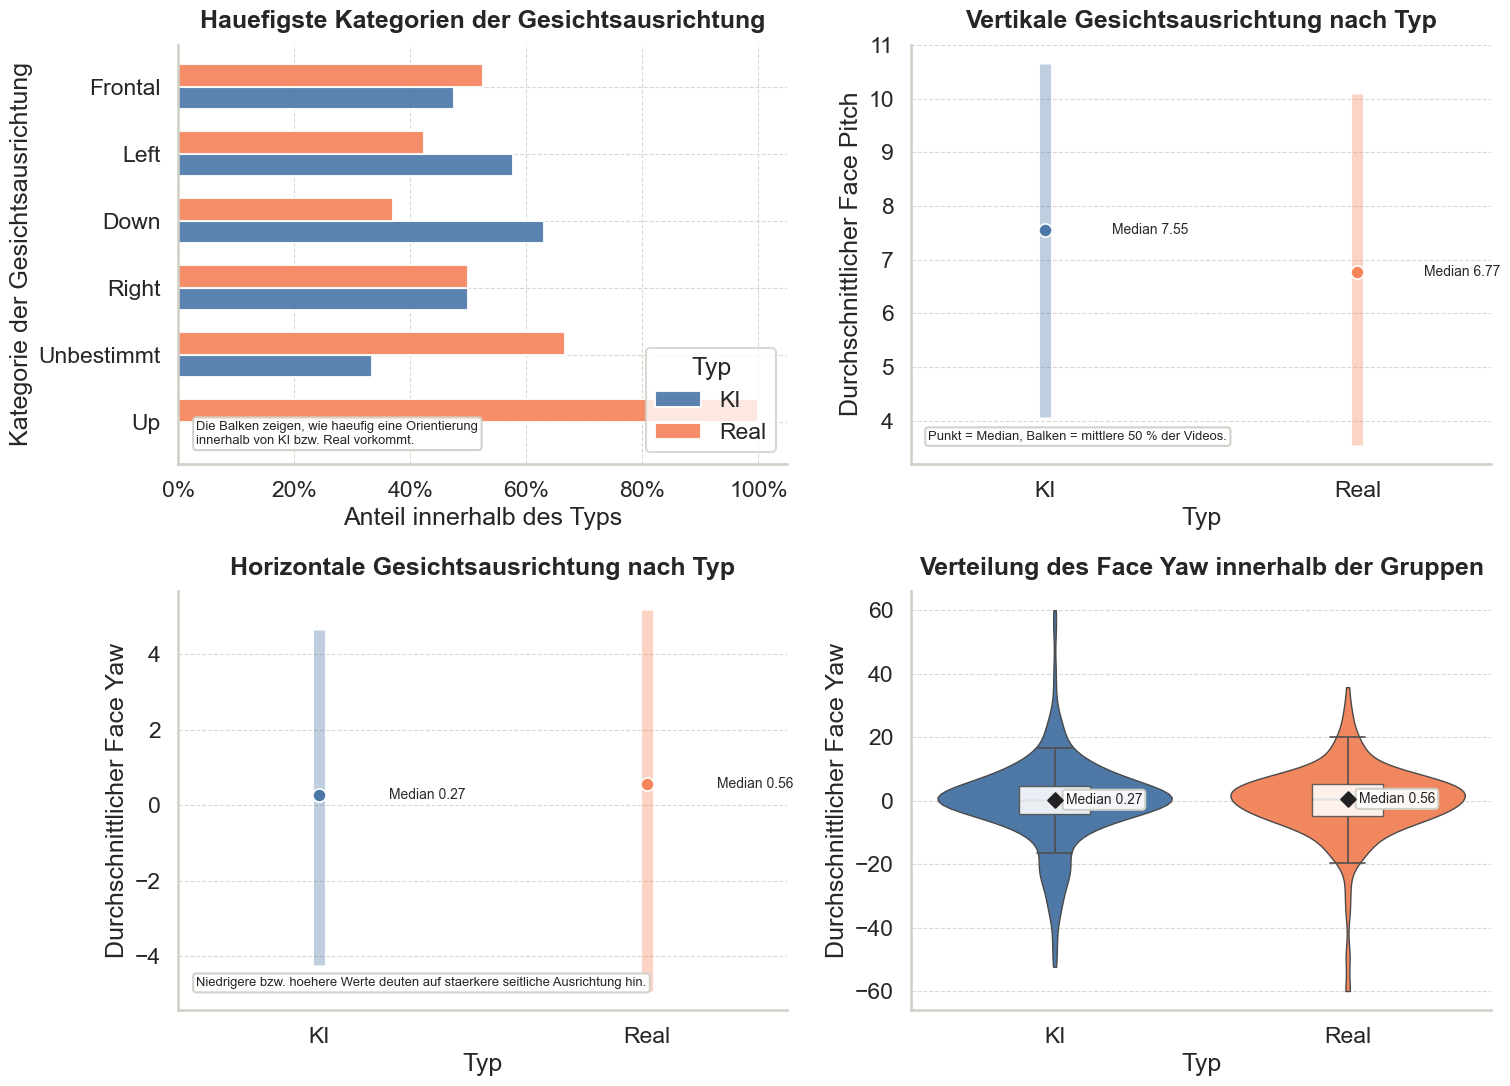

In [14]:
# Visualisierung der Gesichtsausrichtung
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

ORDER = ['KI', 'Real']
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])
orientation_label_map = {
    'frontal': 'Frontal',
    'left': 'Nach links gedreht',
    'right': 'Nach rechts gedreht',
    'up': 'Nach oben geneigt',
    'down': 'Nach unten geneigt',
    'unknown': 'Unbestimmt',
}
df_plot['orientierung_plot'] = df_plot['angle_face_orientation'].map(orientation_label_map).fillna(df_plot['angle_face_orientation'])

orientation_counts = (
    df_plot.groupby(['orientierung_plot', 'typ']).size().unstack(fill_value=0).reindex(columns=ORDER, fill_value=0)
)
orientation_share = orientation_counts.div(orientation_counts.sum(axis=1), axis=0)
orientation_share['gesamt'] = orientation_counts.sum(axis=1)
orientation_share = orientation_share.sort_values('gesamt', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(15.5, 11.2), gridspec_kw={'width_ratios': [1.05, 1.0]})

# 1) Kategorien: Anteil pro Typ als horizontaler Balkenvergleich
bar_height = 0.34
y_pos = np.arange(len(orientation_share.index))
axes[0, 0].barh(y_pos - bar_height / 2, orientation_share['KI'], height=bar_height, color=PALETTE_COLOR['KI'], alpha=0.92, label='KI')
axes[0, 0].barh(y_pos + bar_height / 2, orientation_share['Real'], height=bar_height, color=PALETTE_COLOR['Real'], alpha=0.92, label='Real')
axes[0, 0].set_title('Hauefigste Kategorien der Gesichtsausrichtung', pad=12, weight='semibold')
axes[0, 0].set_xlabel('Anteil innerhalb des Typs')
axes[0, 0].set_ylabel('Kategorie der Gesichtsausrichtung')
axes[0, 0].set_yticks(y_pos)
axes[0, 0].set_yticklabels(orientation_share.index)
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0, 0].legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='lower right')
axes[0, 0].text(
    0.03,
    0.04,
    'Die Balken zeigen, wie haeufig eine Orientierung\ninnerhalb von KI bzw. Real vorkommt.',
    transform=axes[0, 0].transAxes,
    ha='left',
    va='bottom',
    fontsize=9.4,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#d0d0c8', alpha=0.94),
)

# 2) Nickwinkel: Median und IQR
pitch_df = df_plot.dropna(subset=['face_pitch_mean']).copy()
pitch_summary = (
    pitch_df.groupby('typ')['face_pitch_mean']
    .agg(median='median', q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
    .reindex(ORDER)
)
x_positions = [0.0, 0.28]
for x, grp in zip(x_positions, ORDER):
    row = pitch_summary.loc[grp]
    axes[0, 1].vlines(x=x, ymin=row['q1'], ymax=row['q3'], color=PALETTE_COLOR[grp], linewidth=8, alpha=0.35)
    axes[0, 1].scatter(x, row['median'], s=90, color=PALETTE_COLOR[grp], edgecolor='white', linewidth=1.2, zorder=3)
    axes[0, 1].text(x + 0.06, row['median'], f"Median {row['median']:.2f}", va='center', fontsize=10, color='#2a2a2a')
axes[0, 1].set_title('Vertikale Gesichtsausrichtung nach Typ', pad=12, weight='semibold')
axes[0, 1].set_xlabel('Typ')
axes[0, 1].set_ylabel('Durchschnittlicher Face Pitch')
axes[0, 1].set_xticks(x_positions)
axes[0, 1].set_xticklabels(ORDER)
axes[0, 1].set_xlim(-0.12, 0.40)
axes[0, 1].grid(axis='x', visible=False)
axes[0, 1].text(
    0.03,
    0.05,
    'Punkt = Median, Balken = mittlere 50 % der Videos.',
    transform=axes[0, 1].transAxes,
    ha='left',
    va='bottom',
    fontsize=9.4,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#d0d0c8', alpha=0.94),
)

# 3) Gierwinkel: Median und IQR
yaw_df = df_plot.dropna(subset=['face_yaw_mean']).copy()
yaw_summary = (
    yaw_df.groupby('typ')['face_yaw_mean']
    .agg(median='median', q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
    .reindex(ORDER)
)
for x, grp in zip(x_positions, ORDER):
    row = yaw_summary.loc[grp]
    axes[1, 0].vlines(x=x, ymin=row['q1'], ymax=row['q3'], color=PALETTE_COLOR[grp], linewidth=8, alpha=0.35)
    axes[1, 0].scatter(x, row['median'], s=90, color=PALETTE_COLOR[grp], edgecolor='white', linewidth=1.2, zorder=3)
    axes[1, 0].text(x + 0.06, row['median'], f"Median {row['median']:.2f}", va='center', fontsize=10, color='#2a2a2a')
axes[1, 0].set_title('Horizontale Gesichtsausrichtung nach Typ', pad=12, weight='semibold')
axes[1, 0].set_xlabel('Typ')
axes[1, 0].set_ylabel('Durchschnittlicher Face Yaw')
axes[1, 0].set_xticks(x_positions)
axes[1, 0].set_xticklabels(ORDER)
axes[1, 0].set_xlim(-0.12, 0.40)
axes[1, 0].grid(axis='x', visible=False)
axes[1, 0].text(
    0.03,
    0.05,
    "Niedrigere bzw. höhere Werte deuten auf staerkere seitliche Ausrichtung hin.",
    transform=axes[1, 0].transAxes,
    ha='left',
    va='bottom',
    fontsize=9.4,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#d0d0c8', alpha=0.94),
)

# 4) Verteilung des Gierwinkels innerhalb der Gruppen
sns.violinplot(
    data=yaw_df,
    x='typ',
    y='face_yaw_mean',
    order=ORDER,
    palette=PALETTE_COLOR,
    inner=None,
    cut=0,
    linewidth=1.0,
    saturation=0.95,
    ax=axes[1, 1],
)
sns.boxplot(
    data=yaw_df,
    x='typ',
    y='face_yaw_mean',
    order=ORDER,
    width=0.24,
    fliersize=0,
    boxprops={'facecolor': 'white', 'alpha': 0.88, 'edgecolor': '#4f4f4f', 'zorder': 3},
    whiskerprops={'linewidth': 1.2, 'color': '#4f4f4f'},
    capprops={'linewidth': 1.2, 'color': '#4f4f4f'},
    medianprops={'color': '#222222', 'linewidth': 1.8},
    ax=axes[1, 1],
)
for x, grp in enumerate(ORDER):
    median_val = yaw_summary.loc[grp, 'median']
    axes[1, 1].scatter(x, median_val, s=55, color='#222222', marker='D', zorder=4)
    axes[1, 1].annotate(
        f'Median {median_val:.2f}',
        (x, median_val),
        xytext=(8, 0),
        textcoords='offset points',
        va='center',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
    )
axes[1, 1].set_title('Verteilung des Face Yaw innerhalb der Gruppen', pad=12, weight='semibold')
axes[1, 1].set_xlabel('Typ')
axes[1, 1].set_ylabel('Durchschnittlicher Face Yaw')
axes[1, 1].grid(axis='x', visible=False)

for ax in np.ravel(axes):
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()


In [15]:
# Signifikanztests laut Tabelle:
# - face_pitch_mean: t-Test
# - face_yaw_mean: t-Test

results = []
for metric in ['face_pitch_mean', 'face_yaw_mean']:
    ai_vals = df.loc[df['influencer_type'] == 'ai', metric].dropna()
    real_vals = df.loc[df['influencer_type'] == 'real', metric].dropna()

    if len(ai_vals) > 0 and len(real_vals) > 0:
        t_stat, t_p = ttest_ind(ai_vals, real_vals, equal_var=False, nan_policy='omit')
        results.append({
            'metric': metric,
            'n_ai': len(ai_vals),
            'n_real': len(real_vals),
            'mean_ai': ai_vals.mean(),
            'mean_real': real_vals.mean(),
            't_stat': t_stat,
            't_p': t_p,
        })

results_df = pd.DataFrame(results).round(4)
display(results_df)


,metric,n_ai,n_real,mean_ai,mean_real,t_stat,t_p
0,face_pitch_mean,247,244,6.9484,6.2258,1.4219,0.1557
1,face_yaw_mean,247,244,-0.7175,-0.5592,-0.1375,0.8907


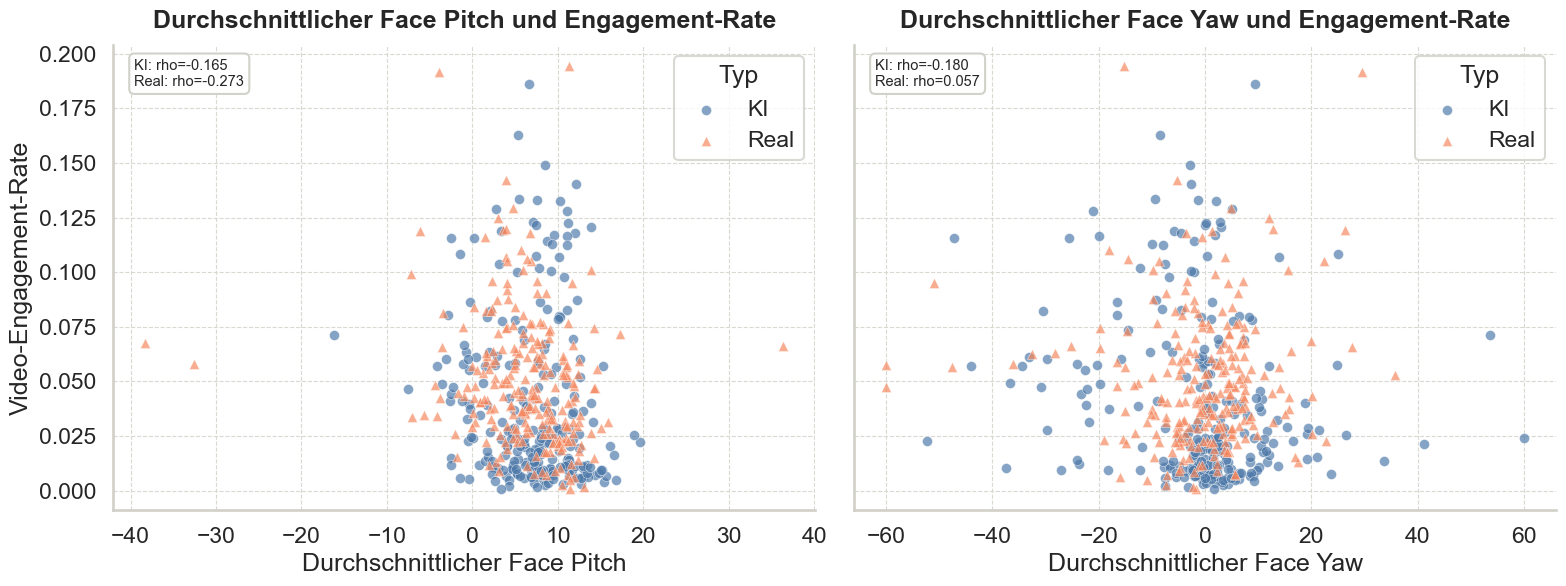

,Metrik,method,Spearman_rho,p_Wert
0,Durchschnittlicher Face Pitch,Spearman,-0.2193,0.0000
1,Durchschnittlicher Face Yaw,Spearman,-0.0849,0.0602


In [16]:
# Korrelationsanalyse laut Tabelle: Spearman (ohne lineare Regression)
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
MARKER = {'KI': 'o', 'Real': '^'}

corr_results = []
metrics = [
    ('face_pitch_mean', 'Durchschnittlicher Face Pitch'),
    ('face_yaw_mean', 'Durchschnittlicher Face Yaw'),
]

if 'video_engagement_rate' in df_plot.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6.2), sharey=True)

    for ax, (metric_col, metric_label) in zip(axes, metrics):
        rho, pval = spearmanr(df_plot[metric_col], df_plot['video_engagement_rate'], nan_policy='omit')
        corr_results.append({'Metrik': metric_label, 'method': 'Spearman', 'Spearman_rho': rho, 'p_Wert': pval})
        stats_lines = []

        for grp in ['KI', 'Real']:
            sub = df_plot[df_plot['typ'] == grp]
            grp_rho, grp_pval = spearmanr(sub[metric_col], sub['video_engagement_rate'], nan_policy='omit')
            stats_lines.append(f'{grp}: rho={grp_rho:.3f}')
            sns.scatterplot(
                data=sub,
                x=metric_col,
                y='video_engagement_rate',
                color=PALETTE_COLOR[grp],
                marker=MARKER[grp],
                edgecolor='white',
                linewidth=0.4,
                s=52,
                alpha=0.68,
                ax=ax,
                label=grp,
            )

        ax.set_title(f'{metric_label} und Engagement-Rate', pad=12, weight='semibold')
        ax.set_xlabel(metric_label)
        if ax is axes[0]:
            ax.set_ylabel('Video-Engagement-Rate')
        else:
            ax.set_ylabel('')

        ax.text(
            0.03,
            0.97,
            '\n'.join(stats_lines),
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=10.5,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
        )
        sns.despine(ax=ax, top=True, right=True)

    handles, labels = axes[0].get_legend_handles_labels()
    legend_handles = handles[:2]
    legend_labels = labels[:2]
    for ax in axes:
        ax.legend(legend_handles, legend_labels, title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='best')

    plt.tight_layout()
    plt.show()
else:
    print('video_engagement_rate column not available; skipping correlation analysis.')

corr_df = pd.DataFrame(corr_results).round(4)
display(corr_df)


In [17]:
print('Kurzinterpretation:')

def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'

if 'results_df' in globals() and not results_df.empty:
    for _, row in results_df.iterrows():
        mean_diff = row['mean_ai'] - row['mean_real']
        direction = 'höherer Mittelwert bei KI' if mean_diff > 0 else ('höherer Mittelwert bei Real' if mean_diff < 0 else 'kein Mittelwertunterschied')
        print(f"- {row['metric']} (t-Test): {sig_label(row['t_p'])} (p={row['t_p']:.4f}). Interpretation: Unterschiedliche Mittelwerte deuten auf unterschiedliche Kameraposition/Blickwinkel hin ({direction}).")

if 'corr_df' in globals() and not corr_df.empty:
    for _, row in corr_df.iterrows():
        rho = row['Spearman_rho']
        p = row['p_Wert']
        direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
        print(f"- Engagement ~ {row['Metrik']} (Spearman): {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: {direction}er monotoner Zusammenhang mit Engagement.")


Kurzinterpretation:
- face_pitch_mean (t-Test): nicht signifikant (p=0.1557). Interpretation: Unterschiedliche Mittelwerte deuten auf unterschiedliche Kameraposition/Blickwinkel hin (höherer Mittelwert bei KI).
- face_yaw_mean (t-Test): nicht signifikant (p=0.8907). Interpretation: Unterschiedliche Mittelwerte deuten auf unterschiedliche Kameraposition/Blickwinkel hin (höherer Mittelwert bei Real).
- Engagement ~ Durchschnittlicher Face Pitch (Spearman): signifikant (rho=-0.219, p=0.0000). Interpretation: negativer monotoner Zusammenhang mit Engagement.
- Engagement ~ Durchschnittlicher Face Yaw (Spearman): nicht signifikant (rho=-0.085, p=0.0602). Interpretation: negativer monotoner Zusammenhang mit Engagement.
